# German NER with Flair

This notebook runs a minimal NER pipeline for the German news corpus using the Flair model `flair/ner-german-large`.

In [6]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

df = pd.read_csv("/Users/katinkakurz/projects/Thesis/data/raw/df_combined.csv")

print(f"Shape: {df.shape}")
display(df.head(3))

Shape: (20440, 5)


,Date,Title,Text,source,row_id
0,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...,Der Streit um das Nationale Anti-Korruptionsbü...,Antispiegel,1
1,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...,Die New York Times versucht seit langem vor Ge...,Antispiegel,2
2,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...,Ende September stehen in Moldawien Parlamentsw...,Antispiegel,3


## Step 1: Prepare the text

Clean `Title` and `Text`, keep a stable `row_id`, and combine title plus article body into one `document_text` field.

In [8]:

for col in ["Title", "Text"]:
    if col not in df.columns:
        raise KeyError(f"Missing required column: {col}")
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

df["document_text"] = (
    "Title: " + df["Title"] + "\nText: " + df["Text"]
).str.replace(r"\s+", " ", regex=True).str.strip()

display(df[["row_id", "Date", "source", "Title", "Text", "document_text"]].head(5))

,row_id,Date,source,Title,Text,document_text
0,1,2025-08-01,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,Der Streit um das Nationale Anti-Korruptionsbü...,Title: Bereitet der Westen die Entmachtung ode...
1,2,2025-08-01,Antispiegel,EU-Kommission hat Textnachrichten zum Kauf der...,Die New York Times versucht seit langem vor Ge...,Title: EU-Kommission hat Textnachrichten zum K...
2,3,2025-08-01,Antispiegel,Wahlkommission rechtfertigt Einmischung der EU...,Ende September stehen in Moldawien Parlamentsw...,Title: Wahlkommission rechtfertigt Einmischung...
3,4,2025-08-02,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,Ich bin auf die Geschichte zuerst bei RT-DE ge...,Title: Fordert Russland wirklich die Vernichtu...
4,5,2025-08-02,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,"Wer auch nicht-westliche Medien liest, der ist...",Title: Der Spiegel macht mal wieder Berichters...


## Step 2: Load the Flair NER model

If Flair is not installed yet, run the install command once, restart the kernel, and then run the cell below.

```python
%pip install flair
```

In [9]:
!pip install flair

  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached langdetect-1.0.9-py3-none-any.whl
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 29.4 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 29.0 MB/s  0:00:00 eta 0:00:01
Using cached ftfy-

In [10]:
from flair.models import SequenceTagger
from flair.splitter import SegtokSentenceSplitter

MODEL_NAME = "flair/ner-german-large"
tagger = SequenceTagger.load(MODEL_NAME)
splitter = SegtokSentenceSplitter()

print(f"Loaded model: {MODEL_NAME}")

pytorch_model.bin:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2026-03-18 20:28:21,664 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, B-PER, E-PER, S-LOC, B-MISC, I-MISC, E-MISC, S-PER, B-ORG, E-ORG, S-ORG, I-ORG, B-LOC, E-LOC, S-MISC, I-PER, I-LOC, <START>, <STOP>
Loaded model: flair/ner-german-large


In [15]:
import time

sample_size = 10
sample_texts = df["document_text"].head(sample_size)

start = time.time()
sample_entities = [extract_entities(text) for text in sample_texts]
elapsed = time.time() - start

minutes_for_full_run = (elapsed / sample_size) * len(df) / 60
hours_for_full_run = minutes_for_full_run / 60

print(f"{sample_size} articles took {elapsed/60:.2f} minutes")
print(f"Estimated full run: {minutes_for_full_run:.1f} minutes")
print(f"Estimated full run: {hours_for_full_run:.2f} hours")


10 articles took 2.41 minutes
Estimated full run: 4921.2 minutes
Estimated full run: 82.02 hours


In [16]:
print(f"Sample documents: {len(sample_entities)}")

for i, entities in enumerate(sample_entities, start=1):
    print(f"\nDocument {i}: {len(entities)} entities")
    if entities:
        display(pd.DataFrame(entities))
    else:
        print("No entities found.")

Sample documents: 10

Document 1: 225 entities


,entity,label,score,start,end
0,Selenskys,PER,0.999980,64,73
1,Nationale Anti-Korruptionsbüro,ORG,0.997042,103,133
2,Ukraine,LOC,0.999968,138,145
3,NABU,ORG,0.999984,147,151
4,NABU,ORG,0.999986,192,196
...,...,...,...,...,...
220,Saluzhny,PER,0.999715,19303,19311
221,Budanow,PER,0.999978,19316,19323
222,Selenskys,PER,0.999995,19405,19414
223,NABU,ORG,0.999987,19497,19501



Document 2: 51 entities


,entity,label,score,start,end
0,EU-Kommission,ORG,0.998219,7,20
1,New York Times,ORG,0.999975,127,141
2,EU-Kommission,ORG,0.999146,180,193
3,von der Leyen,PER,0.999973,263,276
4,Bourla,PER,0.999992,293,299
5,MRNA,MISC,0.998948,366,370
6,Pfizer,ORG,0.999983,388,394
7,Euro,MISC,0.988938,426,430
8,Euro,MISC,0.999941,442,446
9,EU-Kommission,ORG,0.971046,752,765



Document 3: 71 entities


...

,entity,label,score,start,end
0,Putin,PER,0.999989,7,12
1,Lukaschenko,PER,0.999990,17,28
2,NABU,ORG,0.999983,61,65
3,Ukrainische Anti-Korruptionsbüro,ORG,0.999968,94,126
4,NABU,ORG,0.999979,128,132
5,Russlands,LOC,0.999998,273,282
6,Weißrusslands,LOC,0.999998,287,300
7,Putin,PER,0.999989,302,307
8,Lukaschenko,PER,0.999989,312,323
9,Putin,PER,0.999989,549,554



Document 9: 55 entities


,entity,label,score,start,end
0,Spiegel,ORG,0.999977,17,24
1,Merkels,PER,0.999923,60,67
2,Spiegel,ORG,0.999976,97,104
3,Spiegel,ORG,0.999979,324,331
4,Merkels,PER,0.999910,376,383
5,Spiegel,ORG,0.999982,446,453
6,Spiegel,ORG,0.999964,518,525
7,Deutschland,LOC,0.999997,586,597
8,Spiegel,ORG,0.999984,943,950
9,Spiegel,ORG,0.999985,1059,1066



Document 10: 42 entities


,entity,label,score,start,end
0,EU,ORG,0.999980,12,14
1,Russland,LOC,0.999997,19,27
2,Russlands,LOC,0.999997,121,130
3,Weißrusslands,LOC,0.999997,135,148
4,Putin,PER,0.999987,150,155
5,Lukaschenko,PER,0.999986,160,171
6,EU,ORG,0.999762,293,295
7,USA,LOC,0.999978,313,316
8,USA,LOC,0.999990,434,437
9,EU,ORG,0.999880,462,464


## Step 3: Run NER on the corpus

Each article is split into sentences first. Then the model predicts NER tags for those sentences. The extracted entity spans are stored back on article level.

In [18]:
import os
import torch
import flair

# Allow fallback to CPU for ops not implemented on MPS
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

if torch.backends.mps.is_available():
    flair.device = torch.device("mps")
    device_name = "MPS"
elif torch.cuda.is_available():
    flair.device = torch.device("cuda")
    device_name = "CUDA"
else:
    flair.device = torch.device("cpu")
    device_name = "CPU"

# Reload model so it is placed on the selected device
tagger = SequenceTagger.load(MODEL_NAME)
tagger.to(flair.device)

print(f"Using device: {device_name} ({flair.device})")
print(f"Model loaded: {MODEL_NAME}")

2026-03-18 21:09:07,951 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, B-PER, E-PER, S-LOC, B-MISC, I-MISC, E-MISC, S-PER, B-ORG, E-ORG, S-ORG, I-ORG, B-LOC, E-LOC, S-MISC, I-PER, I-LOC, <START>, <STOP>
Using device: MPS (mps)
Model loaded: flair/ner-german-large


In [19]:
def extract_entities(text):
    sentences = splitter.split(text)
    if not sentences:
        return []

    tagger.predict(sentences, mini_batch_size=32)

    entities = []
    for sentence in sentences:
        for span in sentence.get_spans("ner"):
            entities.append(
                {
                    "entity": span.text,
                    "label": span.tag,
                    "score": float(span.score),
                    "start": sentence.start_position + span.start_position,
                    "end": sentence.start_position + span.end_position,
                }
            )

    return entities


In [ ]:
all_entities = []
for idx, text in enumerate(df["document_text"], start=1):
    all_entities.append(extract_entities(text))
    if idx % 100 == 0 or idx == len(df):
        print(f"Processed {idx}/{len(df)} articles")

df["entities"] = all_entities
df["entity_count"] = df["entities"].str.len()

print(f"Documents with at least one entity: {(df['entity_count'] > 0).sum():,}")
print(f"Average entities per document: {df['entity_count'].mean():.2f}")
display(df[["row_id", "source", "Title", "entity_count", "entities"]].head(5))

In [17]:
total_title_tokens = df["Title"].astype(str).str.split().str.len().sum()
print(f"Total token length of the Title column in the corpus: {total_title_tokens:,}")

Total token length of the Title column in the corpus: 169,670


In [20]:
# Run NER on titles only (keeps results in `work` for the next step)
work = df.copy()

title_entities = []
for idx, title in enumerate(work["Title"].fillna("").astype(str), start=1):
    title_entities.append(extract_entities(title))
    if idx % 100 == 0 or idx == len(work):
        print(f"Processed {idx}/{len(work)} titles")

work["entities"] = title_entities
work["entity_count"] = work["entities"].str.len()

print(f"Titles with at least one entity: {(work['entity_count'] > 0).sum():,}")
print(f"Average entities per title: {work['entity_count'].mean():.2f}")
display(work[["row_id", "source", "Title", "entity_count", "entities"]].head(5))

Processed 100/20440 titles
Processed 200/20440 titles
Processed 300/20440 titles
Processed 400/20440 titles
Processed 500/20440 titles
Processed 600/20440 titles
Processed 700/20440 titles
Processed 800/20440 titles
Processed 900/20440 titles
Processed 1000/20440 titles
Processed 1100/20440 titles
Processed 1200/20440 titles
Processed 1300/20440 titles
Processed 1400/20440 titles
Processed 1500/20440 titles
Processed 1600/20440 titles
Processed 1700/20440 titles
Processed 1800/20440 titles
Processed 1900/20440 titles
Processed 2000/20440 titles
Processed 2100/20440 titles
Processed 2200/20440 titles
Processed 2300/20440 titles
Processed 2400/20440 titles
Processed 2500/20440 titles
Processed 2600/20440 titles
Processed 2700/20440 titles
Processed 2800/20440 titles
Processed 2900/20440 titles
Processed 3000/20440 titles
Processed 3100/20440 titles
Processed 3200/20440 titles
Processed 3300/20440 titles
Processed 3400/20440 titles
Processed 3500/20440 titles
Processed 3600/20440 titles
P

,row_id,source,Title,entity_count,entities
0,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,1,"[{'entity': 'Selenskys', 'label': 'PER', 'scor..."
1,2,Antispiegel,EU-Kommission hat Textnachrichten zum Kauf der...,0,[]
2,3,Antispiegel,Wahlkommission rechtfertigt Einmischung der EU...,1,"[{'entity': 'EU', 'label': 'ORG', 'score': 0.9..."
3,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,1,"[{'entity': 'Russland', 'label': 'LOC', 'score..."
4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,1,"[{'entity': 'Spiegel', 'label': 'ORG', 'score'..."


Top 100 most common entities in titles


entity,mentions,unique_titles,unique_sources,labels
Trump,844,842,7,PER
Deutschland,703,700,7,"LOC, MISC"
Russland,638,637,7,LOC
AfD,614,603,7,"MISC, ORG"
USA,598,598,7,LOC
Merz,551,549,7,"LOC, MISC, ORG, PER"
Ukraine,523,523,7,LOC
EU,500,500,7,"LOC, ORG"
Putin,291,291,7,PER
Europa,269,268,7,LOC


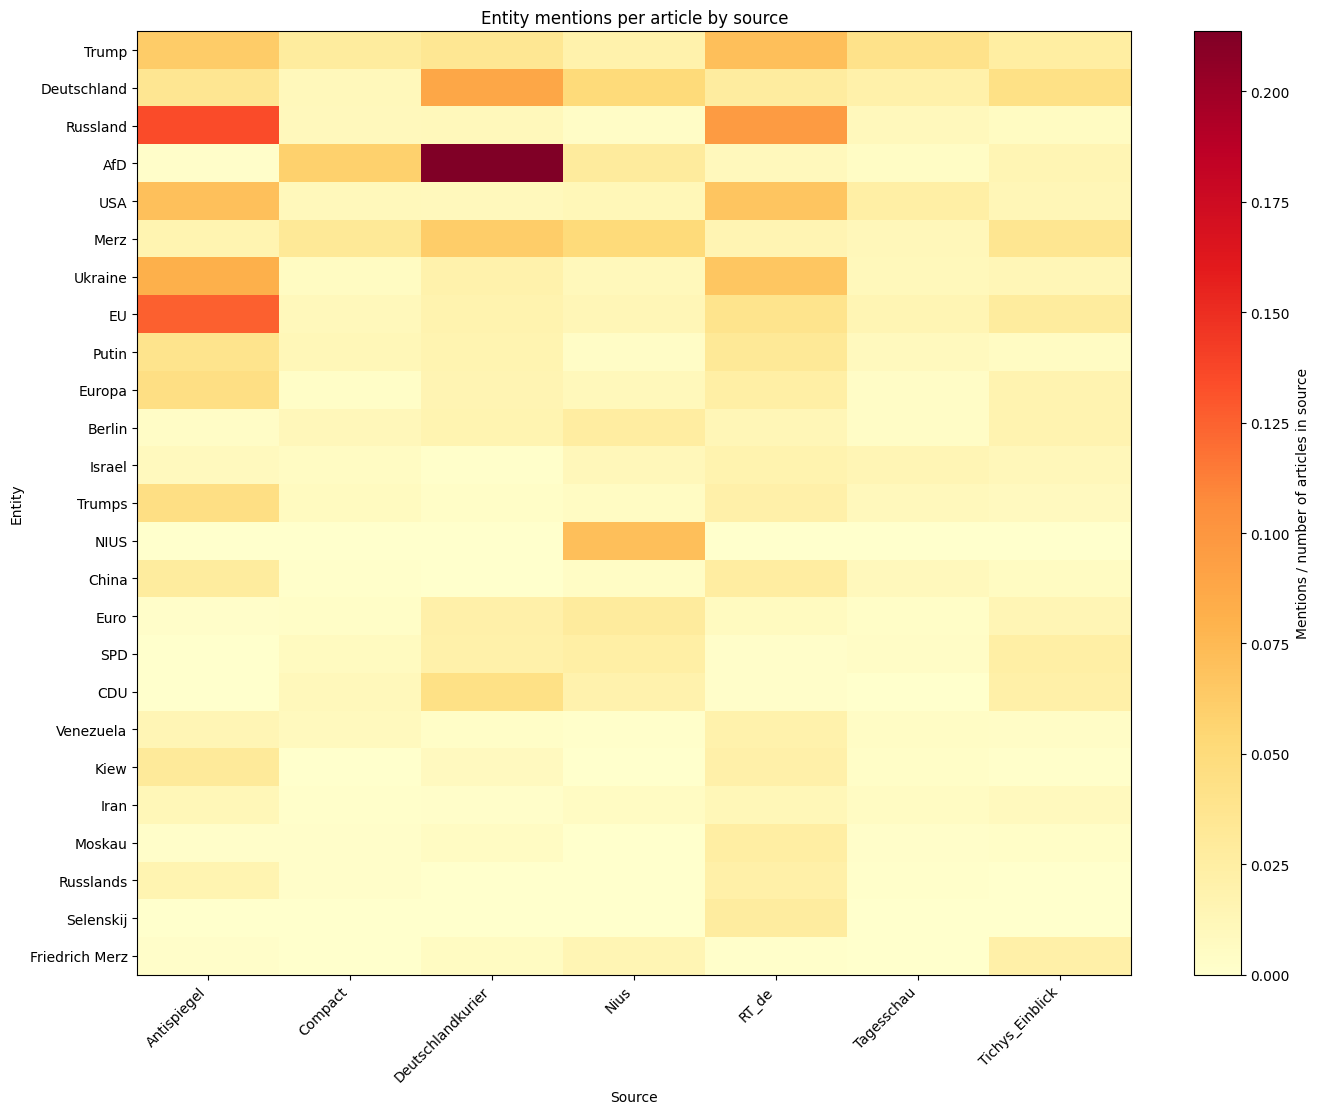

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

TOP_N_TABLE = 100
TOP_N_CHART = 25  # keep smaller for readability

# Flatten title-level entities from `work`
mentions = (
    work[["row_id", "source", "Title", "entities"]]
    .explode("entities")
    .dropna(subset=["entities"])
    .reset_index(drop=True)
)

if mentions.empty:
    print("No entities found in titles.")
else:
    entity_parts = mentions["entities"].apply(pd.Series)
    mentions = pd.concat([mentions.drop(columns="entities"), entity_parts], axis=1)

    mentions["entity"] = mentions["entity"].fillna("").astype(str).str.strip()
    mentions["source"] = mentions["source"].fillna("unknown").astype(str).str.strip()
    mentions["label"] = mentions["label"].fillna("").astype(str).str.strip()
    mentions = mentions[mentions["entity"] != ""].copy()

    # Top 100 entities table
    top_entities = (
        mentions.groupby("entity")
        .agg(
            mentions=("entity", "size"),
            unique_titles=("row_id", "nunique"),
            unique_sources=("source", "nunique"),
            labels=("label", lambda s: ", ".join(sorted(set(s))))
        )
        .sort_values("mentions", ascending=False)
        .head(TOP_N_TABLE)
        .reset_index()
    )

    print(f"Top {TOP_N_TABLE} most common entities in titles")

    # Scrollable table
    html_table = top_entities.to_html(index=False, escape=False)
    display(HTML(f"""
    <div style="max-height: 420px; overflow-y: auto; border: 1px solid #ccc; padding: 8px;">
        {html_table}
    </div>
    """))

    # Normalize by number of articles per source
    articles_per_source = (
        work.groupby("source")["row_id"]
        .nunique()
        .rename("n_articles")
    )

    entities_for_chart = top_entities["entity"].head(TOP_N_CHART)

    entity_source_counts = (
        mentions[mentions["entity"].isin(entities_for_chart)]
        .groupby(["entity", "source"])
        .size()
        .rename("mentions")
        .reset_index()
    )

    entity_source_counts = entity_source_counts.merge(
        articles_per_source.reset_index(),
        on="source",
        how="left"
    )

    entity_source_counts["mentions_per_article"] = (
        entity_source_counts["mentions"] / entity_source_counts["n_articles"]
    )

    plot_data = (
        entity_source_counts
        .pivot(index="entity", columns="source", values="mentions_per_article")
        .fillna(0)
        .loc[entities_for_chart]
    )

    fig, ax = plt.subplots(figsize=(14, max(8, TOP_N_CHART * 0.45)))
    im = ax.imshow(plot_data.values, aspect="auto", cmap="YlOrRd")

    ax.set_yticks(range(len(plot_data.index)))
    ax.set_yticklabels(plot_data.index)
    ax.set_xticks(range(len(plot_data.columns)))
    ax.set_xticklabels(plot_data.columns, rotation=45, ha="right")

    ax.set_title("Entity mentions per article by source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Entity")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mentions / number of articles in source")

    plt.tight_layout()
    plt.show()


In [24]:
import pandas as pd
from IPython.display import HTML, display

# Flatten title-level entities from `work`
mentions = (
    work[["row_id", "source", "Title", "entities"]]
    .explode("entities")
    .dropna(subset=["entities"])
    .reset_index(drop=True)
)

if mentions.empty:
    print("No entities found in titles.")
else:
    entity_parts = mentions["entities"].apply(pd.Series)
    mentions = pd.concat([mentions.drop(columns="entities"), entity_parts], axis=1)

    mentions["entity"] = mentions["entity"].fillna("").astype(str).str.strip()
    mentions = mentions[mentions["entity"] != ""].copy()

    # Top 100 table
    top_entities = (
        mentions.groupby("entity")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(100)
        .reset_index(drop=True)
    )

    print("Top 100 most common entities")
    display(top_entities)

    # Full table with all entities and counts
    all_entities = (
        mentions.groupby("entity")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    print("All entities with counts")

    html_table = all_entities.to_html(index=False)
    display(HTML(f"""
    <div style="max-height: 420px; overflow-y: auto; border: 1px solid #ccc; padding: 8px;">
        {html_table}
    </div>
    """))


Top 100 most common entities


,entity,count
0,Trump,844
1,Deutschland,703
2,Russland,638
3,AfD,614
4,USA,598
...,...,...
95,Moldawien,31
96,ARD,31
97,Merz’,31
98,Bayern,29


All entities with counts


entity,count
Trump,844
Deutschland,703
Russland,638
AfD,614
USA,598
Merz,551
Ukraine,523
EU,500
Putin,291
Europa,269


In [25]:
all_entities = (
    mentions.groupby("entity")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

all_entities.to_csv("all_entities_counts.csv", index=False, encoding="utf-8")
print("Saved to all_entities_counts.csv")


Saved to all_entities_counts.csv


## Step 4: Save the results

Save both article-level and mention-level outputs, plus two small summaries for inspection.

In [ ]:
output_dir = Path("2a_NER/outputs") if Path("2a_NER").exists() else Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

docs_with_entities = work[["row_id", "Date", "source", "Title", "Text", "entity_count"]].copy()
docs_with_entities["entities_json"] = work["entities"].map(lambda value: json.dumps(value, ensure_ascii=False))

entities_long = (
    work[["row_id", "Date", "source", "Title", "entities"]]
    .explode("entities")
    .dropna(subset=["entities"])
    .reset_index(drop=True)
)

if not entities_long.empty:
    entity_parts = entities_long["entities"].apply(pd.Series)
    entities_long = pd.concat([entities_long.drop(columns="entities"), entity_parts], axis=1)
    entities_long = entities_long[["row_id", "Date", "source", "Title", "entity", "label", "score", "start", "end"]]
else:
    entities_long = pd.DataFrame(columns=["row_id", "Date", "source", "Title", "entity", "label", "score", "start", "end"])

entity_summary = (
    entities_long.groupby(["label", "entity"])
    .size()
    .reset_index(name="mentions")
    .sort_values(["label", "mentions", "entity"], ascending=[True, False, True])
)

source_label_summary = (
    entities_long.groupby(["source", "label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

docs_path = output_dir / "ner_documents_flair.csv"
mentions_path = output_dir / "ner_mentions_flair.csv"
summary_path = output_dir / "ner_entity_summary_flair.csv"
source_summary_path = output_dir / "ner_source_label_summary_flair.csv"

docs_with_entities.to_csv(docs_path, index=False, encoding="utf-8")
entities_long.to_csv(mentions_path, index=False, encoding="utf-8")
entity_summary.to_csv(summary_path, index=False, encoding="utf-8")
source_label_summary.to_csv(source_summary_path, index=False, encoding="utf-8")

print(f"Saved document-level output to: {docs_path}")
print(f"Saved mention-level output to:  {mentions_path}")
print(f"Saved entity summary to:        {summary_path}")
print(f"Saved source summary to:        {source_summary_path}")

display(entity_summary.groupby("label").head(10))
display(source_label_summary.head(10))